# SHAP

SHAP feature importance analysis

In [1]:
import numpy as np
import json

import sys
from pathlib import Path
sys.path.append(str(Path().resolve().parents[0]))

def safe_parse(val):
    try:
        if pd.isna(val): return None
    except (TypeError, ValueError): pass
    while isinstance(val, str):
        try: val = ast.literal_eval(val)
        except (ValueError, SyntaxError): break
    return val

In [2]:
import joblib

In [3]:
with open("random_stratified_splits_cls.json") as f:
    splits = json.load(f)

folds        = splits["folds"]
test_idx     = splits["test"]
all_idx      = np.arange(643)
trainval_idx = np.setdiff1d(all_idx, test_idx)
print(f"trainval={len(trainval_idx)}  test={len(test_idx)}  folds={len(folds)}")

trainval=546  test=97  folds=5


In [4]:
import warnings, joblib, xgboost as xgb

with warnings.catch_warnings():
    warnings.simplefilter("ignore")
    clf_xgb  = joblib.load("saved_models_all/cls_xgb_pooled_poly.pkl")   # classifier

In [5]:
X_fp_pooled_poly    = np.load("Vectors/X_fp_pooled_poly.npy")

In [6]:
model = clf_xgb
X     = X_fp_pooled_poly[test_idx]

/Users/xgv7306/miniconda/envs/polyenv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Computing SHAP values...

Top 5 features:
          feature       category  mean_abs_shap
               Pm Global Feature       1.327900
   backbone_atoms   Node Feature       0.741168
        kier_flex   Node Feature       0.473790
             LogP   Node Feature       0.433126
avg_branch_length   Node Feature       0.339365


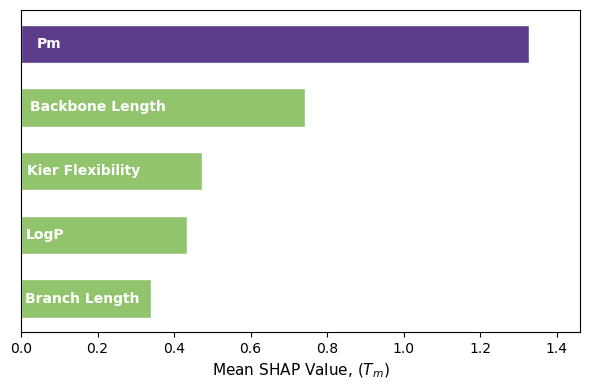

Saved: ./shap_top5_bar_reg.png


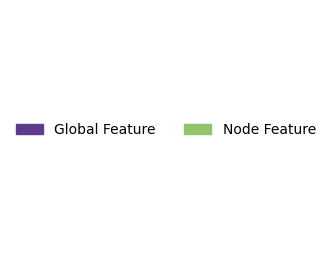

Saved: ./shap_category_legend.png
Saved: ./shap_top5_summary.csv


In [8]:
%run -i scripts/shap_analysis.py